In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import backend as K
from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy
import scipy.stats as stats

sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import utils, vae_functions, generator, model, boxplot, plot

%matplotlib inline
%config InlineBackend.figure_format='retina'

Instructions for updating:
non-resource variables are not supported in the long term


### Load data

In [2]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/' # mag cut at 24.5 in r band
#root_dir_v2 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/26.5/test/' # mag cut at 26.5 in r band

In [3]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

In [42]:
root_dir_models = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'

dir_model_v1 = root_dir_models+'v1/loss/'  # trained on sample with magnitude cut 24.5
dir_model_v2 = root_dir_models+'v4/loss/'  # trained on sample with magnitude cut 26.5

In [11]:
######## Parameters
nb_of_bands = 6
batch_size = 128

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

In [12]:
images = np.load(root_dir_v1+'img_sample.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_sample.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_data.csv')

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])

ellipticity_1 = calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_2 = calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity   = calc_lensed_ellipticity(ell_1, ell_2, shear_1, shear_2, convergence)

e1 = ellipticity_conversion(ellipticity_1)
e2 = ellipticity_conversion(ellipticity_2)

In [13]:
net_v1 = model.create_model_wo_ls_peak_3(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)  #create_model_wo_ls_peak_3
latest = tf.train.latest_checkpoint(dir_model_v2)
net_v1.load_weights(latest)

In [14]:
nb_of_points = 1000
output_v1 = net_v1([tf.cast(images[:nb_of_points], tf.float32), tf.cast(psf[:nb_of_points], tf.float32)])

e1_out_mean = K.get_value(output_v1.mean())[:,0]
e2_out_mean = K.get_value(output_v1.mean())[:,1]

e1_out_std = K.get_value(output_v1.stddev())[:,0]
e2_out_std = K.get_value(output_v1.stddev())[:,1]

Text(0.5, 1.0, '$e2$')

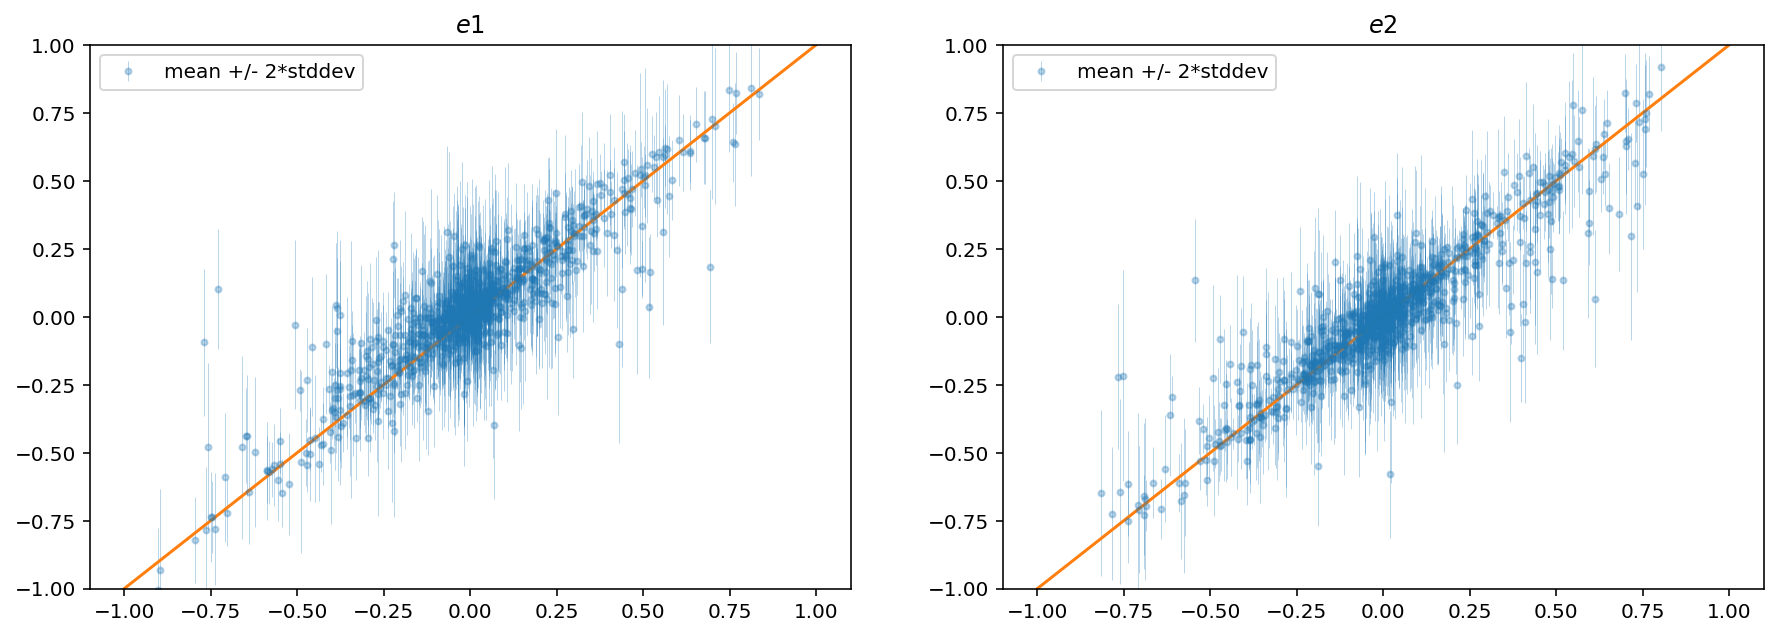

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(-e1[:nb_of_points], e1_out_mean, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)
axes[0].set_title('$e1$')

axes[1].errorbar(e2[:nb_of_points], e2_out_mean, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)
axes[1].set_title('$e2$')

In [16]:
diff_net_e1 = e1_out_mean + e1[:nb_of_points]
diff_net_e2 = e2_out_mean - e2[:nb_of_points]

diff_hsm_e1 = data['e1_hsm_regauss'][:nb_of_points] + e1[:nb_of_points]
diff_hsm_e2 = data['e2_hsm_regauss'][:nb_of_points] - e2[:nb_of_points]

Text(0, 0.5, 'ellipticity error (predict - true)')

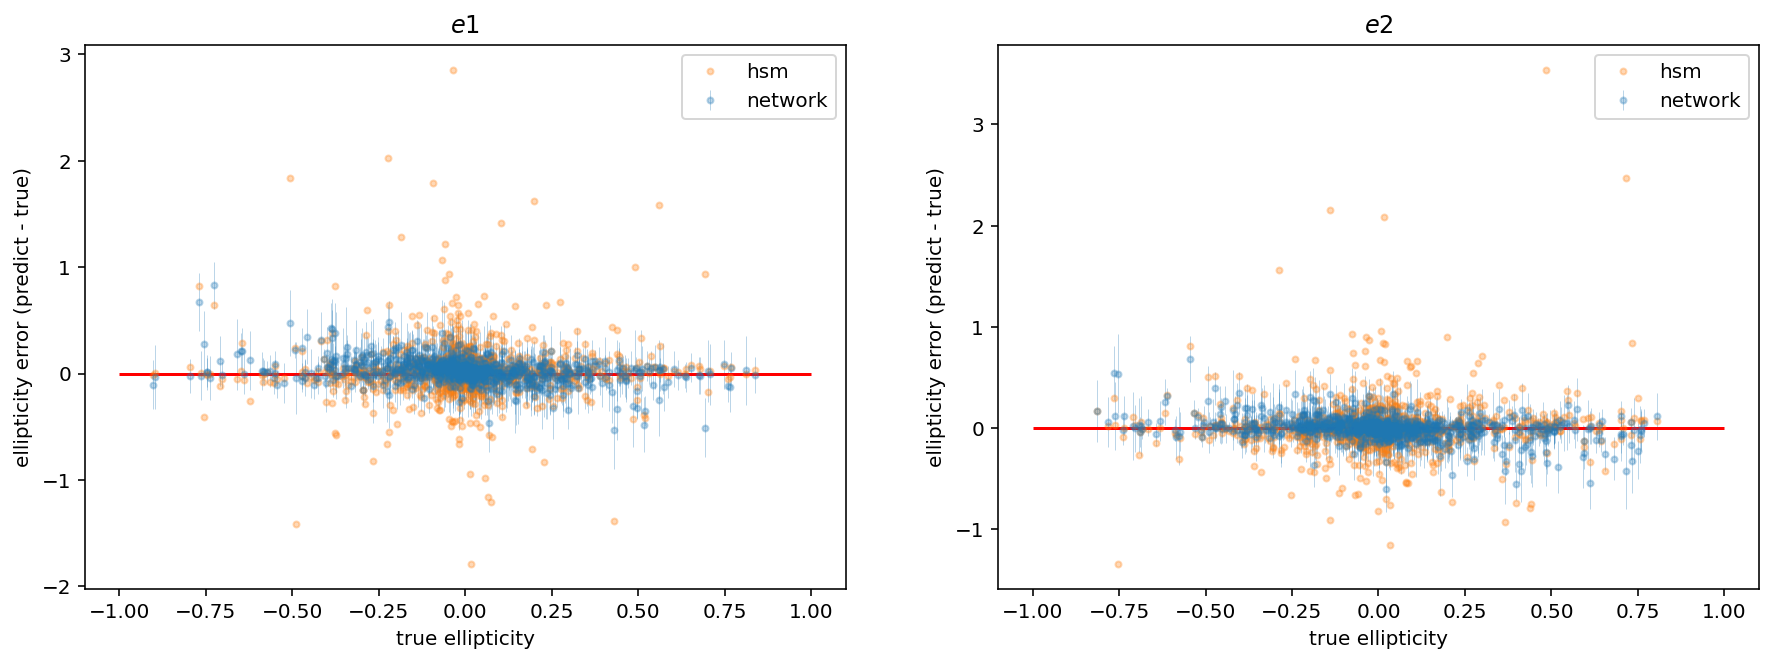

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


axes[0].errorbar(-e1[:nb_of_points], diff_net_e1, yerr = 2*e1_out_std,  fmt='.', elinewidth=0.5, label = 'network', alpha = 0.3)
axes[0].plot(-e1[:nb_of_points], diff_hsm_e1,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].hlines(0,-1,1,'r')
axes[0].legend()

axes[0].set_title('$e1$')
axes[0].set_xlabel('true ellipticity')
axes[0].set_ylabel('ellipticity error (predict - true)')

axes[1].errorbar(e2[:nb_of_points], diff_net_e2, yerr = 2*e2_out_std,  fmt='.', elinewidth=0.5, label = 'network', alpha = 0.3)
axes[1].plot(e2[:nb_of_points], diff_hsm_e2,'.', label = 'hsm', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].hlines(0,-1,1,'r')
axes[1].legend()

axes[1].set_title('$e2$')
axes[1].set_xlabel('true ellipticity')
axes[1].set_ylabel('ellipticity error (predict - true)')

In [19]:
df_plot_hsm = pd.DataFrame()

df_v1 = pd.read_csv(root_dir_v1+'img_data.csv')

df_plot_hsm = pd.concat([df_v1[:nb_of_points], df_v1[:nb_of_points]], ignore_index=True, sort = True)
df_plot_hsm['e1_error'] = np.concatenate([diff_net_e1,diff_hsm_e1])
df_plot_hsm['e2_error'] = np.concatenate([diff_net_e2,diff_hsm_e2])
df_plot_hsm['exp'] = [1]*nb_of_points + [2]*nb_of_points

1998
[1 2]
0 1


/pbs/home/b/barcelin/pbs_throng_link/lsst_stack/conda/miniconda3-py37_4.8.2/envs/lsst-scipipe-1a1d771/lib/python3.7/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


1 2


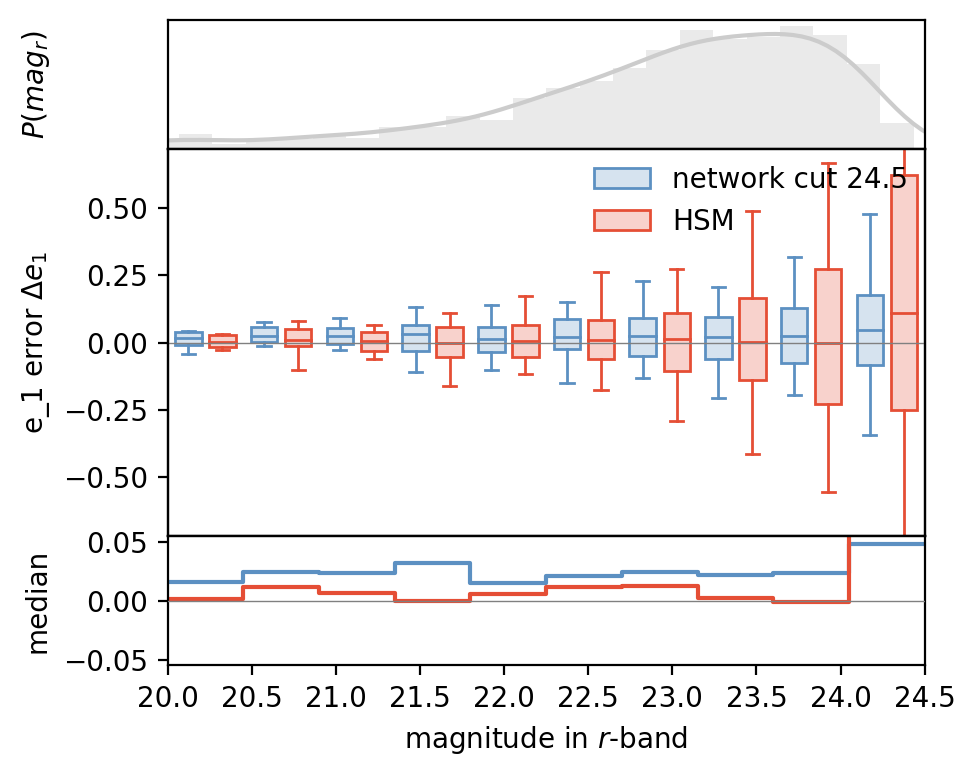

In [22]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_hsm, 
              x = 'mag_r_true', y = 'e1_error', z = 'exp',
              xlim = (20, 24.5),
              ylim = (-0.72, 0.72), 
              ylim2 = (-0.055, 0.055), 
              x_scale = 'linear',
              legend = ['network cut 24.5','HSM'],
              x_label='magnitude in $r$-band', 
              y_label = 'e_1 error $\\Delta e_1$',
              y_label_hist='$P(mag_r)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)

### Shear bias estimation

In [97]:
def boxplot_func_shear_bias(df_in, x,ell, y, z,shear,
            xlim, ylim, ylim2, 
            x_scale, 
            legend,
            x_label, y_label, y_label_hist, y_label_2,
            errors = None,
            legend_remove = False,
            palette = ["#3498db","#e74c3c"],
            nbins = 11):
    
    m = []
    c = []
    err = []
    
    import matplotlib as mpl
    mpl.rcdefaults()
    
    if errors is not None:
        df_plot = df_in.drop(errors)
    else:
        df_plot = df_in

    df_plot = df_plot.dropna()
    print(len(df_plot))
    if x_scale == 'log':
        x_bins = np.geomspace(xlim[0], xlim[1], nbins+1)
    else :
        x_bins = np.linspace(xlim[0], xlim[1], nbins+1)
    
    x_bins[0] -= 1e-5
    x_bins[-1] += 1e-5
    
    idx = np.digitize(df_plot[x], x_bins)    

    fig, axes = plt.subplots(3,1, figsize=(5,4), gridspec_kw={'height_ratios': [1, 3,2]})
    
    if x_scale == 'log':
        sns.distplot(np.log10(df_plot[x]), ax=axes[0], color='0.8')
        axes[0].set_xlim(np.log10(xlim[0]), np.log10(xlim[1]))
    else:
        sns.distplot(df_plot[x], ax=axes[0], color='0.8')
        axes[0].set_xlim(xlim[0], xlim[1])
    
    axes[0].set_yticks([])
    axes[0].set_ylabel(y_label_hist)
    axes[0].set_xticks([])
#####

    exp = np.unique(df_plot[z])
    N_exp = len(exp)
    print(exp)
    handles = []
    for ik, key in enumerate(exp):
        print(ik, key)
        stats = {}
        for i in range(1,len(x_bins)):
            #print(np.mean(df_plot[ell][np.logical_and(idx==i,df_plot[z]==key)].values))
            xx = df_plot[ell][np.logical_and(idx==i,df_plot[z]==key)].values+df_plot[shear][np.logical_and(idx==i,df_plot[z]==key)].values#[np.logical_and(idx==i,df_plot[z]==key)]
            yy = df_plot[y][np.logical_and(idx==i,df_plot[z]==key)].values
            slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(xx,yy)
            #print(slope-1,intercept,)
            m.append(slope-1)
            c.append(intercept)
            err.append(std_err)
        handles = exp
        #plt.setp(key, color=palette[ik])
#####        
    
    ax = axes[1]
    #ax = ax.twiny()
    ax.axhline(y=0, c='0.5', zorder=32, lw=0.5)
    med_array = np.array(m).reshape(N_exp,int(len(m)/N_exp))
    for ik, key in enumerate(exp):
        ax.plot(np.repeat(x_bins,2)[1:-1], np.repeat(med_array[ik],2), c=palette[ik])
    ax.set_xlim(xlim[0], xlim[1])
    if x_scale == 'log':
        ax.set_xscale('log')
    #ax.set_xlim(xlim[0], xlim[1])
    ax.set_xlabel(x_label)
    ax.set_ylim(ylim)
    ax.set_ylabel(y_label)
    ax.xaxis.tick_bottom()
    if not legend_remove:
        ax.legend(handles, legend, frameon=False, loc ='upper right', borderpad = 0.1, fontsize = 10)
           
    fig.align_ylabels(axes)    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0)
    
    
    ax = axes[2]
    #ax = ax.twiny()
    ax.axhline(y=0, c='0.5', zorder=32, lw=0.5)
    med_array = np.array(c).reshape(N_exp,int(len(c)/N_exp))
    for ik, key in enumerate(exp):
        ax.plot(np.repeat(x_bins,2)[1:-1], np.repeat(med_array[ik],2), c=palette[ik])
    ax.set_xlim(xlim[0], xlim[1])
    if x_scale == 'log':
        ax.set_xscale('log')
    ax.set_xlabel(x_label)
    ax.set_ylim(ylim2)
    ax.set_ylabel(y_label_2)
    ax.xaxis.tick_bottom()
            
    fig.align_ylabels(axes)    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0)
    
    return fig , m,c,err

Shear bias: $i = 1,2$


$〈\epsilon_{i,obs}〉=g_{i,obs}=c_i+(1+m_i)g_i$


$g_{i,obs}=c_i+(1+m_i)(〈\epsilon_{i,int}〉+g_i)$

source (https://hal-cea.archives-ouvertes.fr/cea-02949701/document)

or $1+m_i=〈R_{ii}〉$ 

with $ R_{αβ} ≈ \frac{e_{obs,+α}−e_{obs,−α}}{2∆g_β}$ , source (https://www.aanda.org/articles/aa/pdf/2019/01/aa33740-18.pdf)

In [98]:
df_plot_hsm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   blendedness     2000 non-null   float64
 1   convergence     2000 non-null   float64
 2   e1              2000 non-null   float64
 3   e1_hsm_regauss  1998 non-null   float64
 4   e2              2000 non-null   float64
 5   e2_hsm_regauss  1998 non-null   float64
 6   id              2000 non-null   int64  
 7   mag_r_meas      2000 non-null   float64
 8   mag_r_true      2000 non-null   float64
 9   redshift        2000 non-null   float64
 10  redshift_true   2000 non-null   float64
 11  shear_1         2000 non-null   float64
 12  shear_2         2000 non-null   float64
 13  snr_r           2000 non-null   float64
 14  e1_error        1999 non-null   float64
 15  e2_error        1999 non-null   float64
 16  exp             2000 non-null   int64  
 17  e1_meas         1999 non-null   f

In [99]:
df_plot_hsm['e1_meas']= np.concatenate([e1_out_mean, data['e1_hsm_regauss'][:nb_of_points]])
df_plot_hsm['e2_meas']= np.concatenate([e2_out_mean, data['e2_hsm_regauss'][:nb_of_points]])
df_plot_hsm['e1_sheared'] = np.concatenate([-e1[:nb_of_points],-e1[:nb_of_points]])
df_plot_hsm['e2_sheared'] = np.concatenate([e2[:nb_of_points],e2[:nb_of_points]])

In [100]:
ellipticity = calc_lensed_ellipticity(-df_plot_hsm['e1'].values, df_plot_hsm['e2'].values, 0,0, 0)

df_plot_hsm['e1_conv'] = -ellipticity_conversion(df_plot_hsm['e1'])
df_plot_hsm['e2_conv'] = ellipticity_conversion(df_plot_hsm['e2'])

In [111]:
len(m)

20

1998
[1 2]
0 1
1 2


/pbs/home/b/barcelin/pbs_throng_link/lsst_stack/conda/miniconda3-py37_4.8.2/envs/lsst-scipipe-1a1d771/lib/python3.7/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:84: UserWarning: Legend does not support 1 instances.
A proxy artist may be used instead.
See: https://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:84: UserWarning: Legend does not support 2 instances.
A proxy artist may be used instead.
See: https://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists


m1 for network: -0.11099524576016824
m1 for HSM: 0.01512785764445328


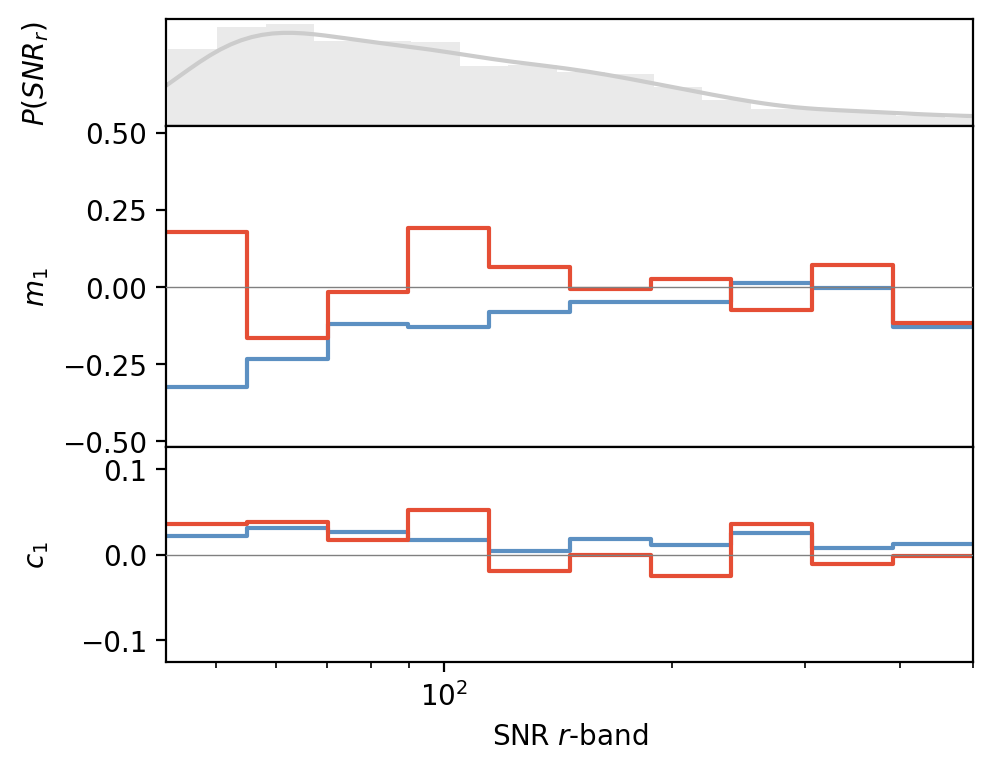

In [118]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'snr_r', ell = 'e1_conv', y = 'e1_meas', z = 'exp', shear = 'shear_1',
              xlim = (43, 500),
              ylim = (-0.52,0.52), 
              ylim2 = (-0.125, 0.125), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'HSM'],
              x_label='SNR $r$-band', 
              y_label = '$m_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_1$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)
print('m1 for network: '+str(np.mean(m[:10])))
print('m1 for HSM: '+str(np.mean(m[10:])))

1998
[1 2]
0 1
1 2


/pbs/home/b/barcelin/pbs_throng_link/lsst_stack/conda/miniconda3-py37_4.8.2/envs/lsst-scipipe-1a1d771/lib/python3.7/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:84: UserWarning: Legend does not support 1 instances.
A proxy artist may be used instead.
See: https://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:84: UserWarning: Legend does not support 2 instances.
A proxy artist may be used instead.
See: https://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists


m2 for network: -0.08909587159616822
m2 for HSM: 0.042327626897310025


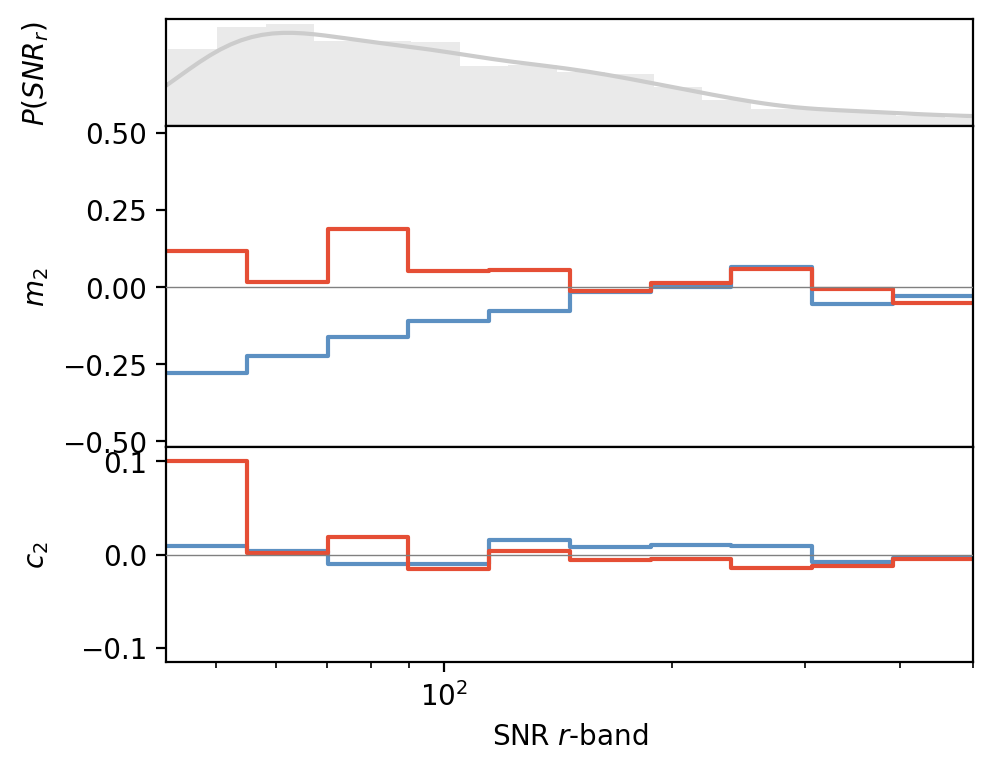

In [114]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'snr_r', ell = 'e2_conv', y = 'e2_meas', z = 'exp', shear = 'shear_2',
              xlim = (43, 500),
              ylim = (-0.52,0.52), 
              ylim2 = (-0.115, 0.115), 
              x_scale = 'log',
              legend = ['network cut 24.5', 'HSM'],
              x_label='SNR $r$-band', 
              y_label = '$m_2$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_2$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)

print('m2 for network: '+str(np.mean(m[:10])))
print('m2 for HSM: '+str(np.mean(m[10:])))

1998
[1 2]
0 1
1 2


/pbs/home/b/barcelin/pbs_throng_link/lsst_stack/conda/miniconda3-py37_4.8.2/envs/lsst-scipipe-1a1d771/lib/python3.7/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:84: UserWarning: Legend does not support 1 instances.
A proxy artist may be used instead.
See: https://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:84: UserWarning: Legend does not support 2 instances.
A proxy artist may be used instead.
See: https://matplotlib.org/users/legend_guide.html#creating-artists-specifically-for-adding-to-the-legend-aka-proxy-artists


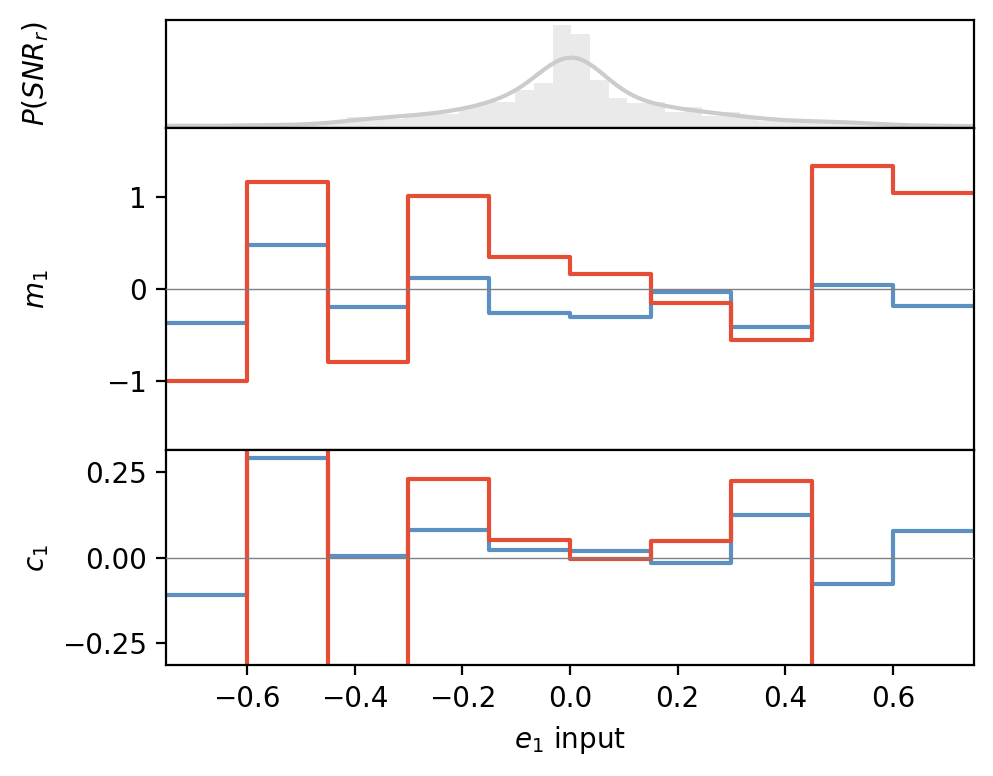

In [107]:
fig, m,c,err = boxplot_func_shear_bias(df_plot_hsm, 
              x = 'e1_conv', ell = 'e1_conv', y = 'e1_meas', z = 'exp', shear = 'shear_1',
              xlim = (-0.75, 0.75),
              ylim = (-1.76,1.76), 
              ylim2 = (-0.315, 0.315), 
              x_scale = 'linear',
              legend = ['network cut 24.5', 'HSM'],
              x_label='$e_1$ input', 
              y_label = '$m_1$',
              y_label_hist='$P(SNR_r)$',
              y_label_2 = '$c_1$',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)

### Applying shear on images

In [120]:
import galsim

#Need to convert image at generation to galsim object, shear it and then work from there

In [ ]:
nb_of_points = 1000
output_v1_001_000 = net_v1([tf.cast(images[:nb_of_points], tf.float32), tf.cast(psf[:nb_of_points], tf.float32)])

e1_out_mean_001_000 = K.get_value(output_v1_001_000.mean())[:,0]
e2_out_mean_001_000 = K.get_value(output_v1_001_000.mean())[:,1]

e1_out_std_001_000 = K.get_value(output_v1_001_000.stddev())[:,0]
e2_out_std_001_000 = K.get_value(output_v1_001_000.stddev())[:,1]